**⚙️ 1. Setup Instructions**

email-phishing-detector/
├── data/
│   └── phishing_validation_emails.csv
├── models/
├── app/
│   └── streamlit_app.py
└── phishing_detector.ipynb
**bold text**

**📦 Step 1 – Imports & Load Dataset**

In [5]:
# Cell 1 - imports
import os
import re
import string
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline


In [6]:
# Cell 2 - load dataset or fallback to small demo
DATA_PATH = "/content/Phishing_validation_emails.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print("Loaded dataset:", DATA_PATH)
else:
    # fallback small demo (for immediate testing)
    data = {
        "text": [
            "Dear user, your bank account has been suspended. Click here to verify: http://bad.example/verify",
            "Meeting tomorrow at 10am — can you confirm?",
            "Your invoice is attached. Please open and pay now.",
            "Reset your password at http://secure-bank.example/reset (urgent)",
            "Lunch at noon? Let's meet at the usual place.",
            "Update required: We couldn't verify your account. Provide credentials here.",
            "Project update: finished module A, pushing to repo."
        ],
        "label": [1, 0, 1, 1, 0, 1, 0]  # 1 -> phishing, 0 -> legitimate
    }
    df = pd.DataFrame(data)
    print("Using fallback demo dataset (small).")

df.shape, df.head(3)


Loaded dataset: /content/Phishing_validation_emails.csv


((2000, 2),
                                           Email Text      Email Type
 0  Dear Jordan, your subscription has been succes...      Safe Email
 1  Dear Casey, thank you for your purchase. Your ...      Safe Email
 2  Congratulations! You've won a $3000 gift card....  Phishing Email)

In [7]:
df

,Email Text,Email Type
0,"Dear Jordan, your subscription has been succes...",Safe Email
1,"Dear Casey, thank you for your purchase. Your ...",Safe Email
2,Congratulations! You've won a $3000 gift card....,Phishing Email
3,You have a new secure message from your bank. ...,Phishing Email
4,Your package delivery is pending. Please provi...,Phishing Email
...,...,...
1995,Your payment has been declined. Update your bi...,Phishing Email
1996,"Hi Taylor, it was great meeting you at the con...",Safe Email
1997,Your subscription is about to expire. Renew no...,Phishing Email
1998,"Hi John, just a reminder about the project dea...",Safe Email


**📂 Step 2 – Load University of Twente Dataset**

In [8]:
# Path to dataset
DATA_PATH = "/content/Phishing_validation_emails.csv"

# Load dataset (adjust encoding if needed)
df = pd.read_csv(DATA_PATH, encoding='utf-8', on_bad_lines='skip')

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Dataset shape: (2000, 2)
Columns: ['Email Text', 'Email Type']


,Email Text,Email Type
0,"Dear Jordan, your subscription has been succes...",Safe Email
1,"Dear Casey, thank you for your purchase. Your ...",Safe Email
2,Congratulations! You've won a $3000 gift card....,Phishing Email
3,You have a new secure message from your bank. ...,Phishing Email
4,Your package delivery is pending. Please provi...,Phishing Email


**🧹 Step 3 – Clean & Prepare Data**

In [9]:
# Inspect unique label names
print("Unique labels:", df['Email Type'].unique() if 'Email Type' in df.columns else "Check dataset columns")

# Rename if needed
if 'label' not in df.columns:
    df.rename(columns={'Email Type': 'label'}, inplace=True)

if 'text' not in df.columns:
    df.rename(columns={'Email Text': 'text'}, inplace=True)

# Map labels to binary (1 = phishing, 0 = legitimate)
df['label'] = df['label'].astype(str).str.lower().map({
    'phishing email': 1, 'safe email': 0
}).fillna(df['label']).astype(int)

print(df.head(3))
print(df['label'].value_counts())

Unique labels: ['Safe Email' 'Phishing Email']
                                                text  label
0  Dear Jordan, your subscription has been succes...      0
1  Dear Casey, thank you for your purchase. Your ...      0
2  Congratulations! You've won a $3000 gift card....      1
label
0    1000
1    1000
Name: count, dtype: int64


**🧽 Step 4 – Text Cleaning**

In [10]:
def clean_text(s):
    if pd.isna(s):
        return ""
    s = s.lower()
    s = re.sub(r'https?://\S+|www\.\S+', ' ', s)  # remove URLs
    s = re.sub(r'\S+@\S+', ' ', s)                # remove emails
    s = re.sub(r'\d+', ' ', s)                    # remove numbers
    s = s.translate(str.maketrans('', '', string.punctuation))
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text', 'label']].head()


,text,clean_text,label
0,"Dear Jordan, your subscription has been succes...",dear jordan your subscription has been success...,0
1,"Dear Casey, thank you for your purchase. Your ...",dear casey thank you for your purchase your or...,0
2,Congratulations! You've won a $3000 gift card....,congratulations youve won a gift card click he...,1
3,You have a new secure message from your bank. ...,you have a new secure message from your bank c...,1
4,Your package delivery is pending. Please provi...,your package delivery is pending please provid...,1


**🔀 Step 5 – Train/Test Split**

In [11]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", len(X_train), "Test:", len(X_test))


Train: 1600 Test: 400


**🤖 Step 6 – Model Pipeline (TF-IDF + Logistic Regression)**

In [12]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_df=0.95, min_df=2)),
    ('clf', LogisticRegression(solver='liblinear', class_weight='balanced'))
])

param_grid = {
    'clf__C': [0.1, 1.0, 5.0],
    'tfidf__max_features': [5000, 10000, None],
}

grid = GridSearchCV(pipeline, param_grid, cv=4, scoring='f1', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

print("✅ Best Parameters:", grid.best_params_)
model = grid.best_estimator_


Fitting 4 folds for each of 9 candidates, totalling 36 fits
✅ Best Parameters: {'clf__C': 0.1, 'tfidf__max_features': 5000}


**📊 Step 7 – Evaluate Model**

In [13]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Confusion Matrix:
 [[200   0]
 [  0 200]]


**💾 Step 8 – Save Model**

In [15]:
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/phishing_detector_utwente.joblib")
print("Model saved to models/phishing_detector_utwente.joblib")


Model saved to models/phishing_detector_utwente.joblib


**🧪 Step 9 – Test Prediction**

In [16]:
def predict_email(text):
    cleaned = clean_text(text)
    pred = model.predict([cleaned])[0]
    label = "PHISHING ⚠️" if pred == 1 else "LEGITIMATE ✅"
    return label

sample = "Your account has been locked. Click this link to verify immediately."
print("Email:", sample)
print("Prediction:", predict_email(sample))


Email: Your account has been locked. Click this link to verify immediately.
Prediction: PHISHING ⚠️


**EDA**

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="coolwarm")


**📊 2. Visualize class distribution**

/tmp/ipython-input-77263625.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


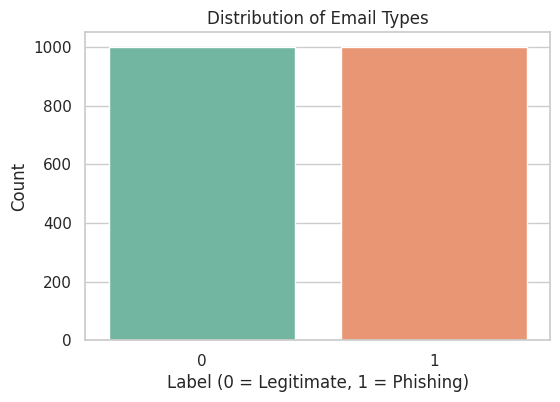

Phishing emails: 50.00% | Legitimate emails: 50.00%


In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title("Distribution of Email Types")
plt.xlabel("Label (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Count")
plt.show()

phish_ratio = df['label'].mean() * 100
print(f"Phishing emails: {phish_ratio:.2f}% | Legitimate emails: {100 - phish_ratio:.2f}%")


**🗣️ 3. Check email length distribution**

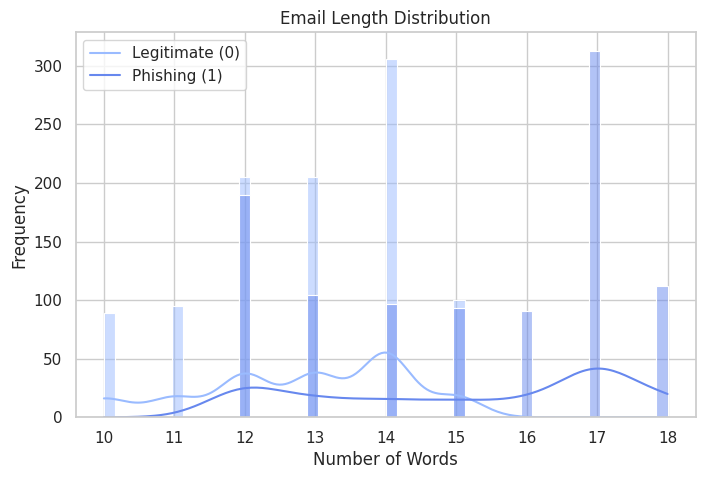

,email_length
label,
0,15.178
1,12.844


In [20]:
df['email_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='email_length', hue='label', bins=50, kde=True)
plt.title("Email Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend(labels=['Legitimate (0)', 'Phishing (1)'])
plt.show()

df[['email_length','label']].groupby('label').mean()


**🔤 4. Word Cloud of Phishing vs Legitimate Emails (optional)**

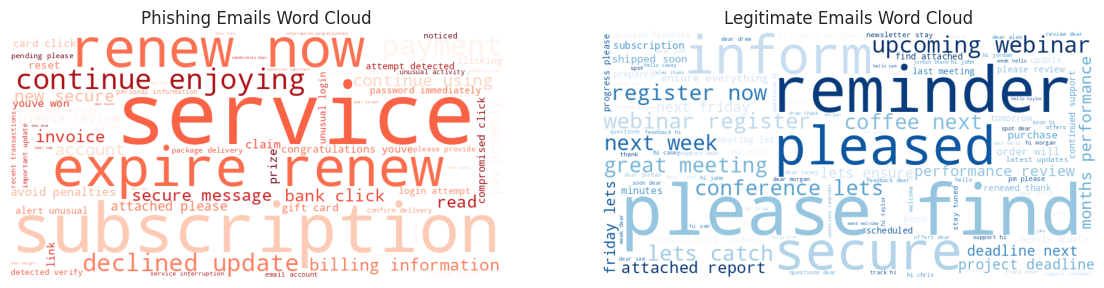

In [21]:
from wordcloud import WordCloud

# Generate two word clouds
phish_text = " ".join(df[df['label'] == 1]['clean_text'])
legit_text = " ".join(df[df['label'] == 0]['clean_text'])

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(phish_text))
plt.title("Phishing Emails Word Cloud")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(legit_text))
plt.title("Legitimate Emails Word Cloud")
plt.axis('off')

plt.show()


**🧩 5. Common Keywords by Category**

In [22]:
from collections import Counter
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def top_words(texts, n=15):
    all_words = " ".join(texts).split()
    filtered = [w for w in all_words if w not in stop_words and len(w) > 3]
    return pd.DataFrame(Counter(filtered).most_common(n), columns=['Word','Frequency'])

print("Top words in PHISHING emails:")
display(top_words(df[df['label']==1]['clean_text']))

print("Top words in LEGITIMATE emails:")
display(top_words(df[df['label']==0]['clean_text']))


Top words in PHISHING emails:


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Word,Frequency
0,account,377
1,click,305
2,continue,222
3,information,203
4,update,199
5,service,199
6,please,196
7,review,196
8,avoid,192
9,unusual,188


Top words in LEGITIMATE emails:


,Word,Frequency
0,please,391
1,dear,313
2,meeting,300
3,lets,216
4,next,216
5,find,207
6,attached,207
7,thank,201
8,review,201
9,reminder,199


**📈 6. Correlation of Text Features**

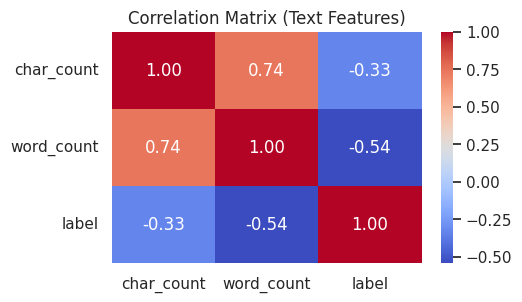

In [23]:
df['char_count'] = df['clean_text'].apply(len)
df['word_count'] = df['email_length']

corr = df[['char_count', 'word_count', 'label']].corr()

plt.figure(figsize=(5,3))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Text Features)")
plt.show()


**🧩 Optional — Display sample phishing vs legit emails**

In [24]:
print("🔹 Sample Phishing Email:")
print(df[df['label']==1].sample(1)['text'].values[0])

print("\n🔹 Sample Legitimate Email:")
print(df[df['label']==0].sample(1)['text'].values[0])


🔹 Sample Phishing Email:
Alert: Unusual login attempt detected. Verify your account by clicking here.

🔹 Sample Legitimate Email:
Hi Drew, it was great meeting you at the conference. Let's catch up for coffee next week.


In [17]:
import streamlit as st
import joblib
import re, string

MODEL_PATH = "../models/phishing_detector_utwente.joblib"

def clean_text(s):
    s = s.lower()
    s = re.sub(r'https?://\S+|www\.\S+', ' ', s)
    s = re.sub(r'\S+@\S+', ' ', s)
    s = re.sub(r'\d+', ' ', s)
    s = s.translate(str.maketrans('', '', string.punctuation))
    s = re.sub(r'\s+', ' ', s).strip()
    return s

@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)

st.title("🕵️ Email Phishing Detector (University of Twente Dataset)")
st.write("Paste an email message below to detect if it’s **Phishing or Legitimate**.")

email_text = st.text_area("Enter email text:", height=300)
model = load_model()

if st.button("Detect"):
    cleaned = clean_text(email_text)
    pred = model.predict([cleaned])[0]
    if pred == 1:
        st.error("🚨 Phishing Email Detected!")
    else:
        st.success("✅ Legitimate Email")
